Name: Divyadharshini S
Roll no: 24BAD022


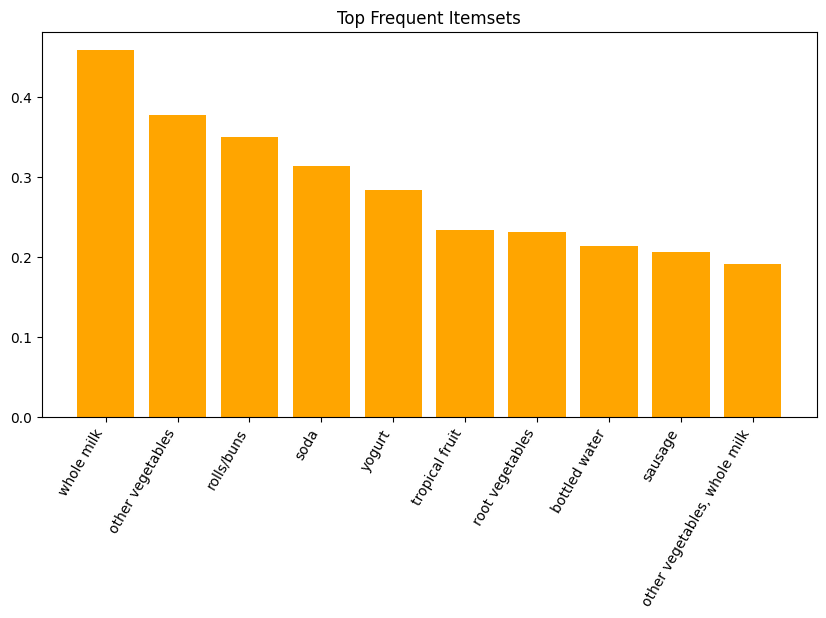

   antecedents          consequents   support  confidence      lift
0  (UHT-milk,)  (other vegetables,)  0.038994    0.496732  1.318979
1  (UHT-milk,)        (rolls/buns,)  0.031042    0.395425  1.130863
2  (UHT-milk,)              (soda,)  0.027450    0.349673  1.115406
3  (UHT-milk,)        (whole milk,)  0.040534    0.516340  1.126928
4      (beef,)  (other vegetables,)  0.050795    0.424893  1.128223


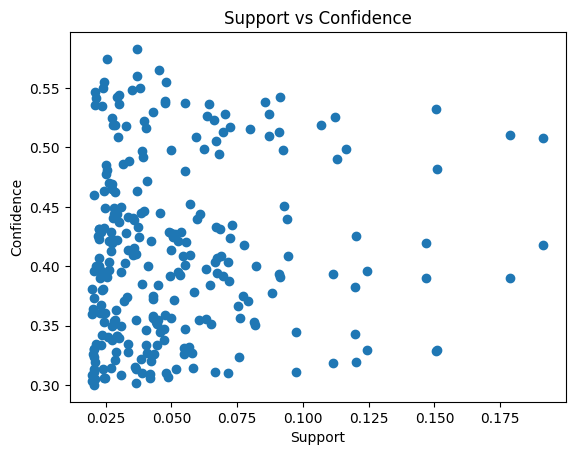

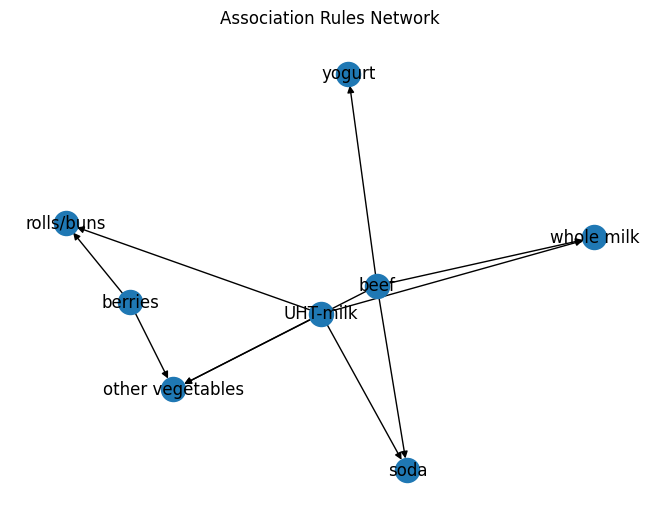

The frequent items: 586
Number of Rules: 267


In [2]:
print("Name: Divyadharshini S\nRoll no: 24BAD022")
import pandas as pd
import matplotlib.pyplot as plt
import itertools
from collections import Counter
import networkx as nx
from mlxtend.frequent_patterns import apriori, association_rules
data = pd.read_csv(r"C:\Users\divya\Downloads\Groceries_dataset.csv")
transactions = data.groupby('Member_number')['itemDescription'].apply(list).tolist()
total_transactions = len(transactions)
def get_support(itemset):
    count = 0
    for t in transactions:
        if set(itemset).issubset(set(t)):
            count += 1
    return count / total_transactions
items = sorted(set(item for t in transactions for item in t))
min_support = 0.02
frequent_itemsets = {}
for i in range(1, 3):
    for combo in itertools.combinations(items, i):
        sup = get_support(combo)
        if sup >= min_support:
            frequent_itemsets[combo] = sup
rules = []
for itemset in frequent_itemsets:
    if len(itemset) > 1:
        for i in range(1, len(itemset)):
            for antecedent in itertools.combinations(itemset, i):
                consequent = tuple(set(itemset) - set(antecedent))
                sup_itemset = frequent_itemsets[itemset]
                sup_ante = frequent_itemsets.get(antecedent, get_support(antecedent))
                sup_cons = frequent_itemsets.get(consequent, get_support(consequent))
                confidence = sup_itemset / sup_ante
                lift = confidence / sup_cons
                if confidence >= 0.3 and lift > 1:
                    rules.append((antecedent, consequent, sup_itemset, confidence, lift))
rules_df = pd.DataFrame(rules, columns=['antecedents', 'consequents', 'support', 'confidence', 'lift'])
top_items = sorted(frequent_itemsets.items(), key=lambda x: x[1], reverse=True)[:10]
plt.figure(figsize=(10,5))
labels = [', '.join(item[0]) for item in top_items]
plt.bar(range(len(top_items)), [x[1] for x in top_items],color = 'orange')
plt.xticks(range(len(top_items)), labels, rotation=60, ha='right')
plt.title("Top Frequent Itemsets")
plt.show()
plt.figure()
print(rules_df.head())
plt.scatter(rules_df['support'], rules_df['confidence'])
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence")
plt.show()
G = nx.DiGraph()
for _, row in rules_df.head(10).iterrows():
    for a in row['antecedents']:
        for c in row['consequents']:
            G.add_edge(a, c)
plt.figure()
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True)
plt.title("Association Rules Network")
plt.show()
print("The frequent items:",len(frequent_itemsets))
print("Number of Rules:",len(rules_df))

Name: Divyadharshini S
Roll no: 24BAD022

Dataset Preview:
   Unnamed: 0 SepalLengthCm  SepalWidthCm PetalLengthCm  PetalWidthCm  \
0           1           5.1           3.5           1.4           0.2   
1           2           4.9           NaN           1.4           0.2   
2           3           4.7           3.2           1.3           0.2   
3           4            ??           3.1           1.5           0.2   
4           5             5           3.6           ###           0.2   

       Species  
0  Iris-setosa  
1          NaN  
2  Iris-setosa  
3  Iris-setosa  
4  Iris-setosa  

Explained Variance Ratio:
[0.72186801 0.23027395 0.03897306 0.00888498]

Optimal number of components (k): 2


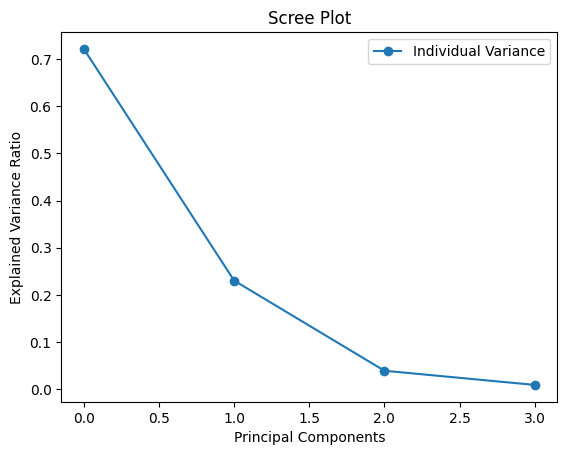

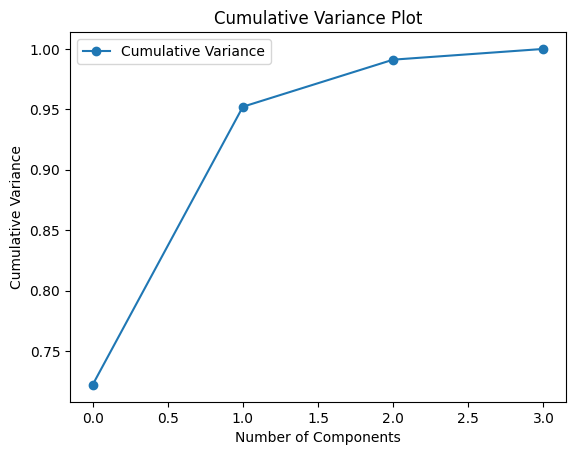

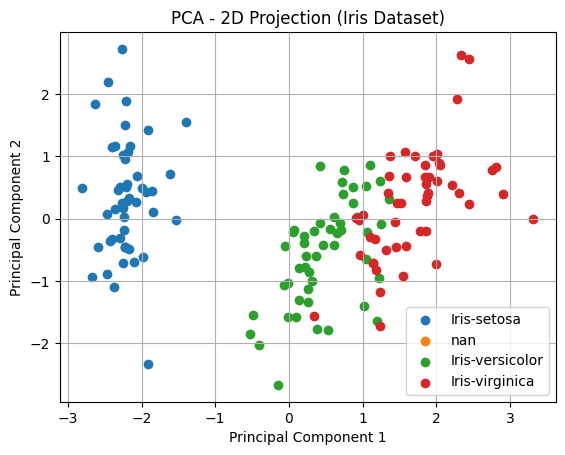

Original Data Shape: (150, 4)

Reduced Data Shape: (150, 2)


In [41]:
print("Name: Divyadharshini S\nRoll no: 24BAD022")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
data = pd.read_csv(r"C:\Users\divya\Downloads\Iris_data_sample.csv")
print("\nDataset Preview:")
print(data.head())
X = data[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
y = data['Species']
X = X.replace('??', np.nan)
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(X.mean())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
print("\nExplained Variance Ratio:")
print(explained_variance)
k = np.argmax(cumulative_variance >= 0.90) + 1
print("\nOptimal number of components (k):", k)
plt.figure()
plt.plot(explained_variance, marker='o', label="Individual Variance")
plt.title("Scree Plot")
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.legend()
plt.show()
plt.figure()
plt.plot(cumulative_variance, marker='o', label="Cumulative Variance")
plt.title("Cumulative Variance Plot")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.legend()
plt.show()
pca_2 = PCA(n_components=2)
X_reduced = pca_2.fit_transform(X_scaled)
plt.figure()
for species in data['Species'].unique():
    indices = data['Species'] == species
    plt.scatter(X_reduced[indices, 0],
                X_reduced[indices, 1],
                label=species)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - 2D Projection (Iris Dataset)")
plt.legend()
plt.grid()
plt.show()
print("Original Data Shape:", X.shape)
print("\nReduced Data Shape:", X_reduced.shape)